# Modélisation - Anemia Prediction

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement et préparation

In [2]:
df = pd.read_csv('anemia.csv')

X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline
numeric_cols = ['Hemoglobin', 'MCH', 'MCHC', 'MCV']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

## 3. Modèles

In [3]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
    print(f"{name}: Accuracy={accuracy_score(y_test, y_pred):.4f}")

# Meilleur modèle
best_name = max(results, key=lambda x: x['F1-Score'])['Modèle']
print(f"\n🏆 Meilleur modèle: {best_name}")

Logistic Regression: Accuracy=0.9860
Random Forest: Accuracy=1.0000


Gradient Boosting: Accuracy=1.0000
XGBoost: Accuracy=1.0000
SVM: Accuracy=0.9860

🏆 Meilleur modèle: Random Forest


In [4]:
# Sauvegarder le meilleur modèle
best_model = models[best_name]
best_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', best_model)])
best_pipeline.fit(X_train, y_train)

joblib.dump(best_pipeline, 'best_model.pkl')
print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !


## 4. Évaluation

=== PERFORMANCES FINALES ===
Accuracy: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


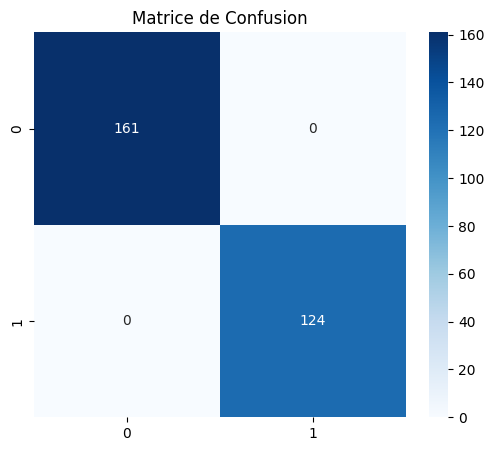

In [5]:
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("=== PERFORMANCES FINALES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Matrice de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.show()

## 5. Importance des variables

On vérifie quelles variables pèsent le plus dans la décision du modèle (cohérent avec la matrice de corrélation de l'EDA).

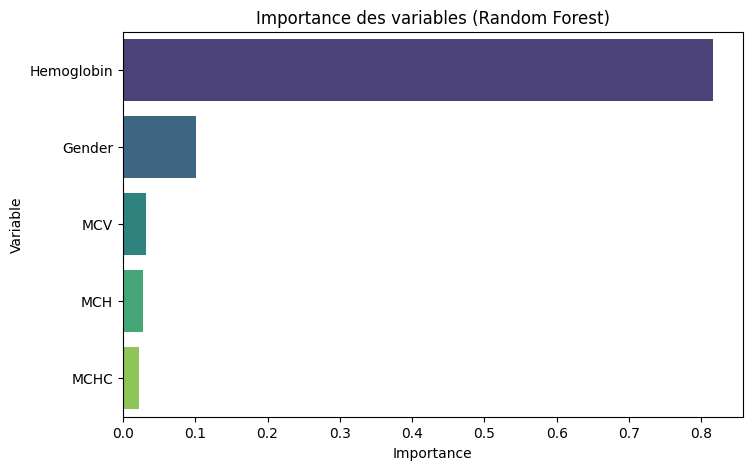

In [6]:
if hasattr(best_model, 'feature_importances_'):
    feat_names = numeric_cols + ['Gender']
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    imp_df = pd.DataFrame({'Variable': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='Importance', y='Variable', palette='viridis')
    plt.title(f'Importance des variables ({best_name})')
    plt.show()
else:
    print("Le modèle sélectionné ne fournit pas d'attribut feature_importances_ directement.")